# 15 · 3-D visualization with PyVista

Digital-Earth's **true-3D tier** renders pyramids data as interactive 3-D scenes through [`Scene3D`](../../reference/three_d.md) (a thin host over a `pyvista.Plotter`). Every plot is built from **pyramids-sourced NumPy + geometry** — no `xarray`/`rasterio`; pyramids owns all GIS/CRS.

This notebook renders each new plot type **off-screen** (so it runs headless in CI) and shows the resulting frame inline. The tier needs the optional `3d` extra (`pip install 'digitalearth[3d]'` → pyvista, trame, geovista, imageio).

**Setup.** Render headless, locate the bundled sample data, and define a small helper that screenshots a scene and shows it inline (asserting the frame is not blank).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: scenes render to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title=''):
    """Screenshot a Scene3D off-screen and display it inline (fails if the render is blank)."""
    img = scene.screenshot()
    assert img.any(), 'render is blank'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


2026-06-11 20:05:41 | INFO | pyramids.base.config | Logging is configured.


## Terrain — a DEM as 3-D relief

`Scene3D.terrain` warps a raster by its elevation into a `StructuredGrid`. PyVista adds a scalar bar automatically.

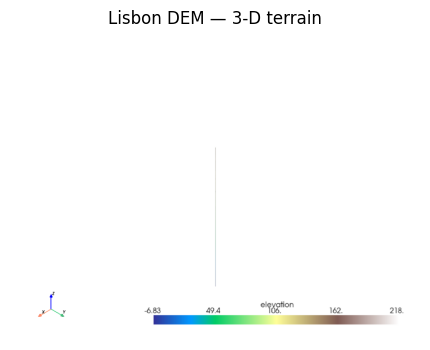

In [2]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain')
scene.plotter.add_axes()
show(scene, 'Lisbon DEM — 3-D terrain')
scene.close()


## Point cloud — scattered points with eye-dome lighting

`Scene3D.point_cloud` renders an `(N, 3)` table (here the DEM sampled to xyz) as depth-cued points coloured by a scalar.

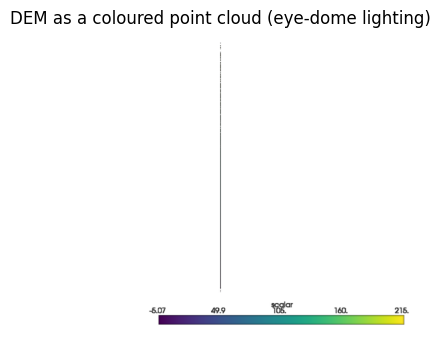

In [3]:
arr = dem.read_array()
xx, yy = np.meshgrid(dem.x[::4], dem.y[::4])
zz = arr[::4, ::4]
pts = np.column_stack([xx.ravel(), yy.ravel(), zz.ravel()])
pts = pts[np.isfinite(pts[:, 2])]
scene = Scene3D(off_screen=True)
scene.point_cloud(pts, values=pts[:, 2], point_size=3.0, cmap='viridis')
show(scene, 'DEM as a coloured point cloud (eye-dome lighting)')
scene.close()


## Volume & isosurfaces — a 3-D scalar field

`Scene3D.volume` ray-casts a 3-D NumPy cube `(level, lat, lon)`; `Scene3D.isosurface` extracts shells of constant value.

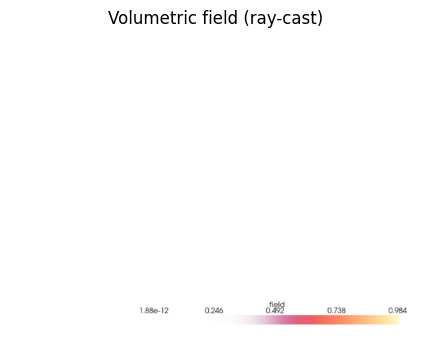

In [4]:
axis = np.linspace(-3, 3, 28)
X, Y, Z = np.meshgrid(axis, axis, axis, indexing='ij')
cube = np.exp(-(X**2 + Y**2 + Z**2)) + 0.5 * np.exp(-((X - 1.5)**2 + (Y + 1.0)**2 + Z**2))
scene = Scene3D(off_screen=True)
scene.volume(cube, cmap='magma', opacity='sigmoid')
show(scene, 'Volumetric field (ray-cast)')
scene.close()


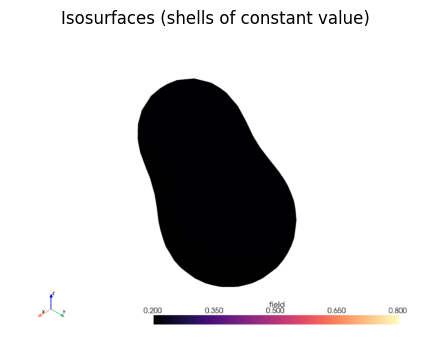

In [5]:
scene = Scene3D(off_screen=True)
scene.isosurface(cube, isosurfaces=[0.2, 0.5, 0.8], cmap='magma')
scene.plotter.add_axes()
show(scene, 'Isosurfaces (shells of constant value)')
scene.close()


## Vectors & extruded polygons

`Scene3D.vectors` draws a `(u, v, w)` field as arrow glyphs; `Scene3D.extruded_polygons` turns polygon footprints into 3-D prisms (height & colour by an attribute).

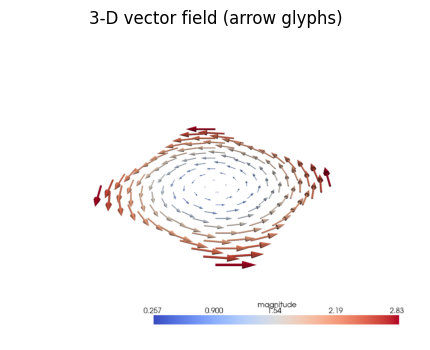

In [6]:
axis = np.linspace(-2, 2, 12)
X, Y = np.meshgrid(axis, axis)
anchors = np.column_stack([X.ravel(), Y.ravel(), np.zeros(X.size)])
field = np.column_stack([-Y.ravel(), X.ravel(), np.zeros(X.size)])  # rotational (u, v, w)
scene = Scene3D(off_screen=True)
scene.vectors(anchors, field, factor=0.3, cmap='coolwarm')
show(scene, '3-D vector field (arrow glyphs)')
scene.close()


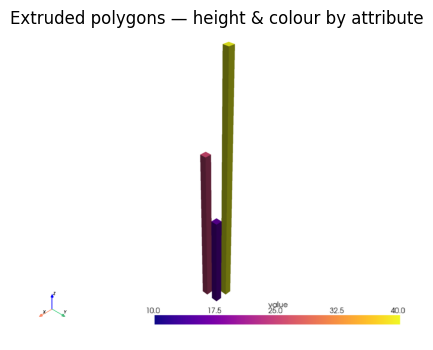

In [7]:
import geopandas as gpd
from shapely.geometry import Polygon
squares = gpd.GeoDataFrame(
    {'pop': [10.0, 25.0, 40.0, 15.0]},
    geometry=[
        Polygon([(0, 0), (1, 0), (1, 1), (0, 1)]), Polygon([(2, 0), (3, 0), (3, 1), (2, 1)]),
        Polygon([(0, 2), (1, 2), (1, 3), (0, 3)]), Polygon([(2, 2), (3, 2), (3, 3), (2, 3)]),
    ],
)
scene = Scene3D(off_screen=True)
scene.extruded_polygons(squares, height='pop', column='pop', cmap='plasma')
scene.plotter.add_axes()
show(scene, 'Extruded polygons — height & colour by attribute')
scene.close()


## Globe — a global field on a textured sphere

`Scene3D.globe` drapes a lon/lat field onto a WGS84 sphere (via the optional geovista) with Natural-Earth coastlines. The field must be in lon/lat — reproject upstream in pyramids (`dataset.to_crs(4326)`) for projected rasters.

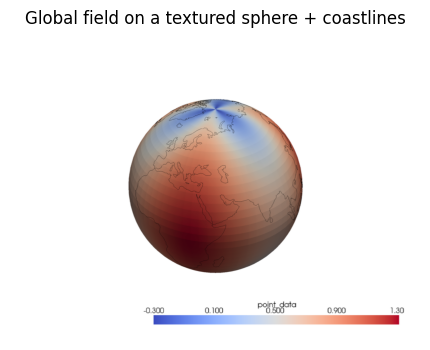

In [8]:
lon = np.linspace(-180, 180, 73)
lat = np.linspace(-90, 90, 37)
global_field = np.add.outer(np.cos(np.deg2rad(lat)), 0.3 * np.sin(np.deg2rad(3 * lon)))
scene = Scene3D(off_screen=True)
scene.globe(get_source(global_field, x=lon, y=lat), cmap='coolwarm', coastlines=True)
show(scene, 'Global field on a textured sphere + coastlines')
scene.close()


## Animation — an orbit fly-through

`Scene3D.orbit` sweeps the camera around the scene and writes a GIF/MP4. Here we orbit the Lisbon terrain and show the animated GIF inline.

orbit GIF bytes: 93396


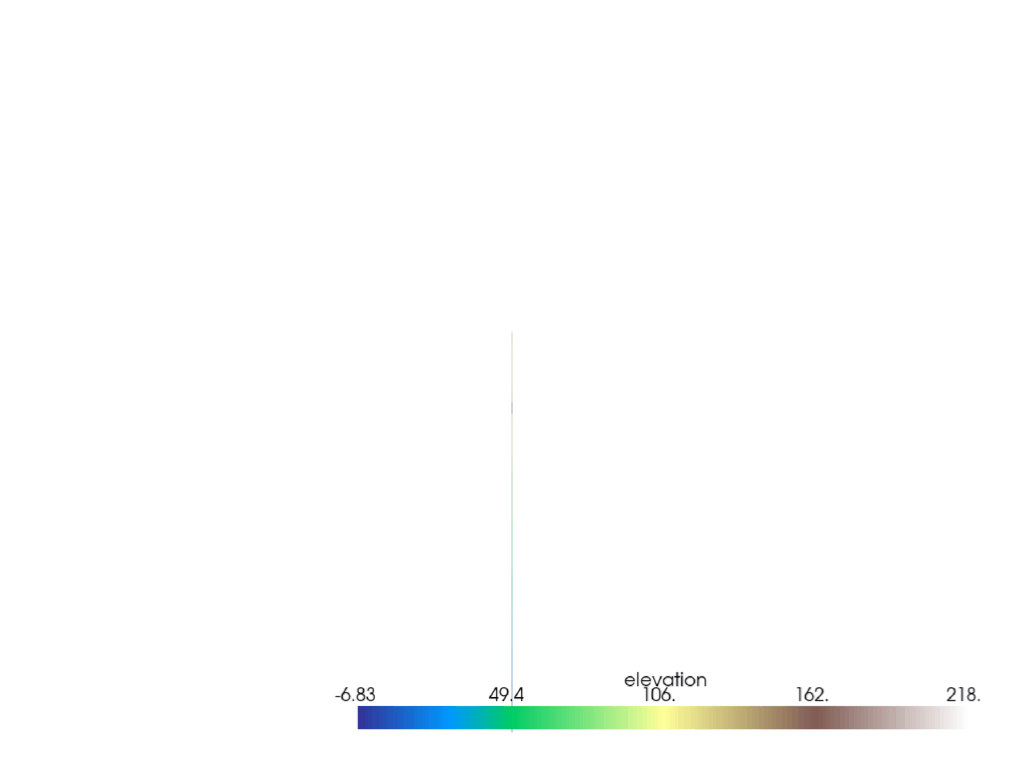

In [9]:
import os, tempfile
from IPython.display import Image as IPyImage, display
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain')
gif = str(Path(tempfile.mkdtemp()) / 'lisbon_orbit.gif')  # temp dir: no repo artifact
scene.orbit(gif, n_frames=12, framerate=12)
scene.close()
print('orbit GIF bytes:', os.path.getsize(gif))
display(IPyImage(filename=gif))
